# M62: equivalent SDOF vs 3D NLTHA

Compares, for archetype **M62** in both directions:

1. **Peak displacements**: SDOF NLTHA (`Pushover_SDOF/ResultsM62x_SDOF`, `ResultsM62y_SDOF`) vs 3D NLTHA
   (`M62_biron_DispX.txt`, `M62_biron_DispY.txt`, largest peak over the braced nodes).
   The SDOF displacement is converted to the braced nodes with `SDOF_FACTOR`, by default
   $\Gamma \cdot \max\phi$ over the spring DOFs of the 2D pushover step the SDOF was built from.
   IMs or records the SDOF analyses have not reached yet are left out; rerun the notebook to update.
2. **Displaced shapes**: mean ± 2σ of the 3D NLTHA shapes (`M62_bironDispShapeX/Y.npy`) vs the equivalent
   static shape (`Pushover2D/pushover_results_M62x/y.txt`), on the plan of the 3D model, whole system
   and zoomed on the line analysed by the 2D model.

Helpers in [nltha_comparison.py](nltha_comparison.py).

In [9]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from nltha_comparison import *

mpl.rc('font', family='Times New Roman')
mpl.rc('mathtext', fontset='stix')
%matplotlib inline

In [10]:
MODEL       = 'M62'
DC_TARGET   = 12.0          # 2D pushover step (mm) of the SDOF calibration and of the static shape
SDOF_FACTOR = 'gamma_phi'   # SDOF -> braced-node displacement: 'gamma_phi', a number, or {'X': .., 'Y': ..}
SHAPE_IM    = 6             # intensity level (1-10) of the NLTHA displaced shapes
AMP         = None          # amplification of the displaced shapes (m per unit); None = automatic

## Peak displacements

In [11]:
comp = peak_comparison(MODEL, factor=SDOF_FACTOR, dc_target=DC_TARGET)
peak_table(comp)

X                                       Y                      \
   3D (mm) SDOF (mm) SDOF / 3D n 3D / SDOF 3D (mm) SDOF (mm) SDOF / 3D   
IM                                                                       
1    2.800     2.964     1.059     44 / 44   2.910     3.100     1.065   
2    5.700     6.024     1.057     44 / 44   5.990     6.324     1.056   
3    8.430     9.268     1.099     44 / 44   8.555     9.881     1.155   
4   10.310    11.842     1.149     44 / 44  10.860    12.313     1.134   
5   14.040    15.626     1.113     44 / 44  14.200    16.334     1.150   
6   16.120    17.986     1.116     44 / 44  16.570    19.329     1.167   
7   19.780    22.581     1.142     44 / 44  20.690    24.245     1.172   
8   23.355    26.567     1.138     44 / 44  23.670    28.510     1.204   
9   26.690    30.179     1.131     44 / 44  28.225    32.930     1.167   
10  29.870    33.160     1.110     44 / 44  32.130    35.591     1.108   

                
   n 3D / SDOF  
IM              
1      44 / 44  
2      44 / 44  
3      44 / 44  
4      44 / 44  
5      44 / 44  
6      44 / 44  
7      44 / 44  
8      44 / 44  
9      44 / 44  
10     44 / 44

Median (markers) and 16th–84th percentiles (bars) over the records.

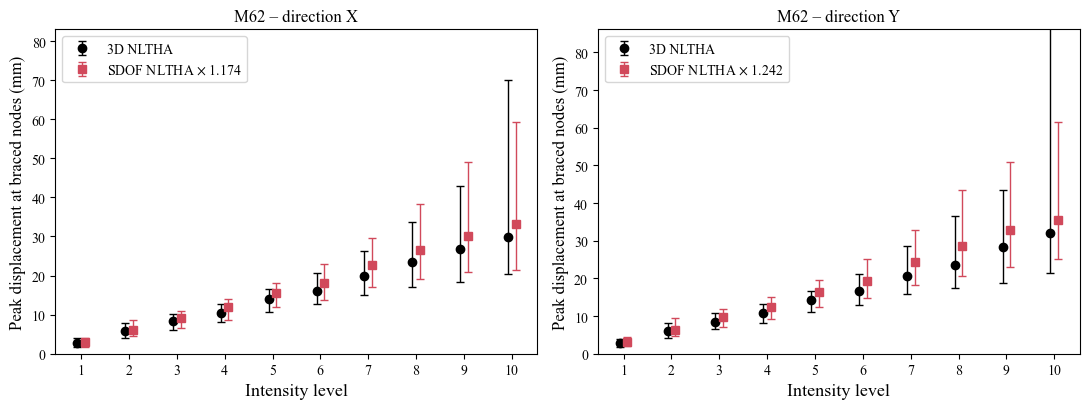

In [12]:
plot_peak_medians(MODEL, comp)
plt.show()

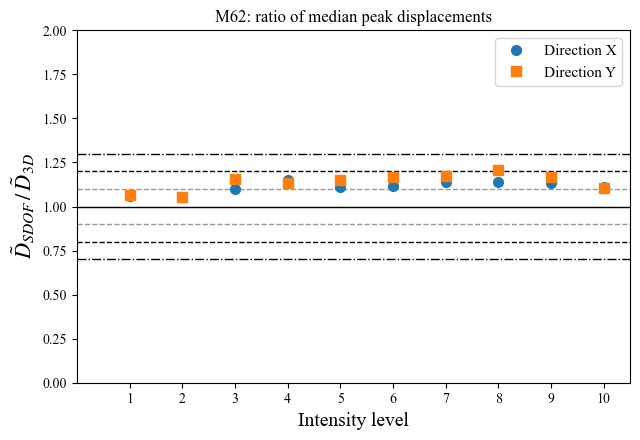

In [13]:
plot_peak_ratio(MODEL, comp)
plt.show()

Record by record (same record and IM in both analyses); dashed lines at ±20 %.

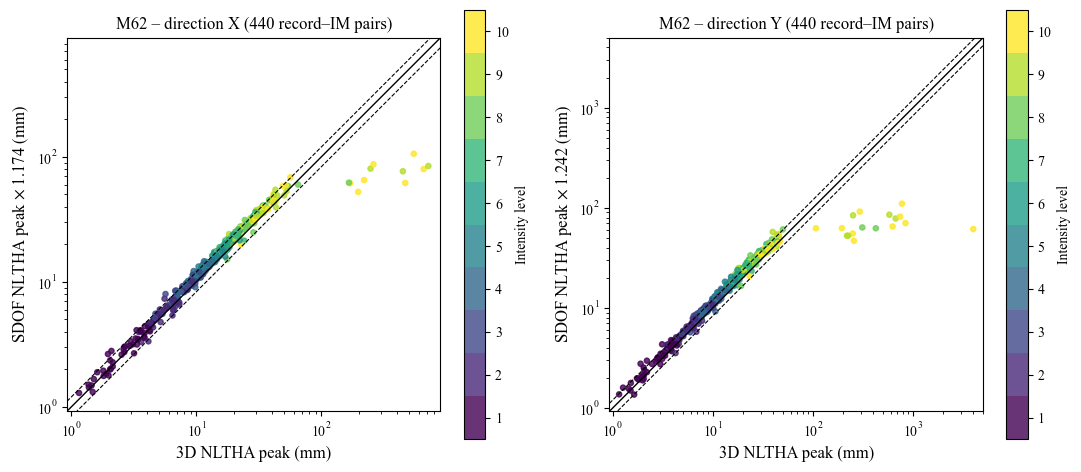

In [14]:
plot_peak_records(MODEL, comp)
plt.show()

## Displaced shapes

Both shapes are normalized to 1 at the marked node (the reference DOF of the 2D model). The static shape
is mapped onto the 3D plan through the analysed line of the 2D model (`nltha_lines` in
`Pushover2D/CS_Lumped_Iter_M62*_cont_PO.py`): pipes parallel to the excitation move rigidly, other
branches deform as the analysed line.

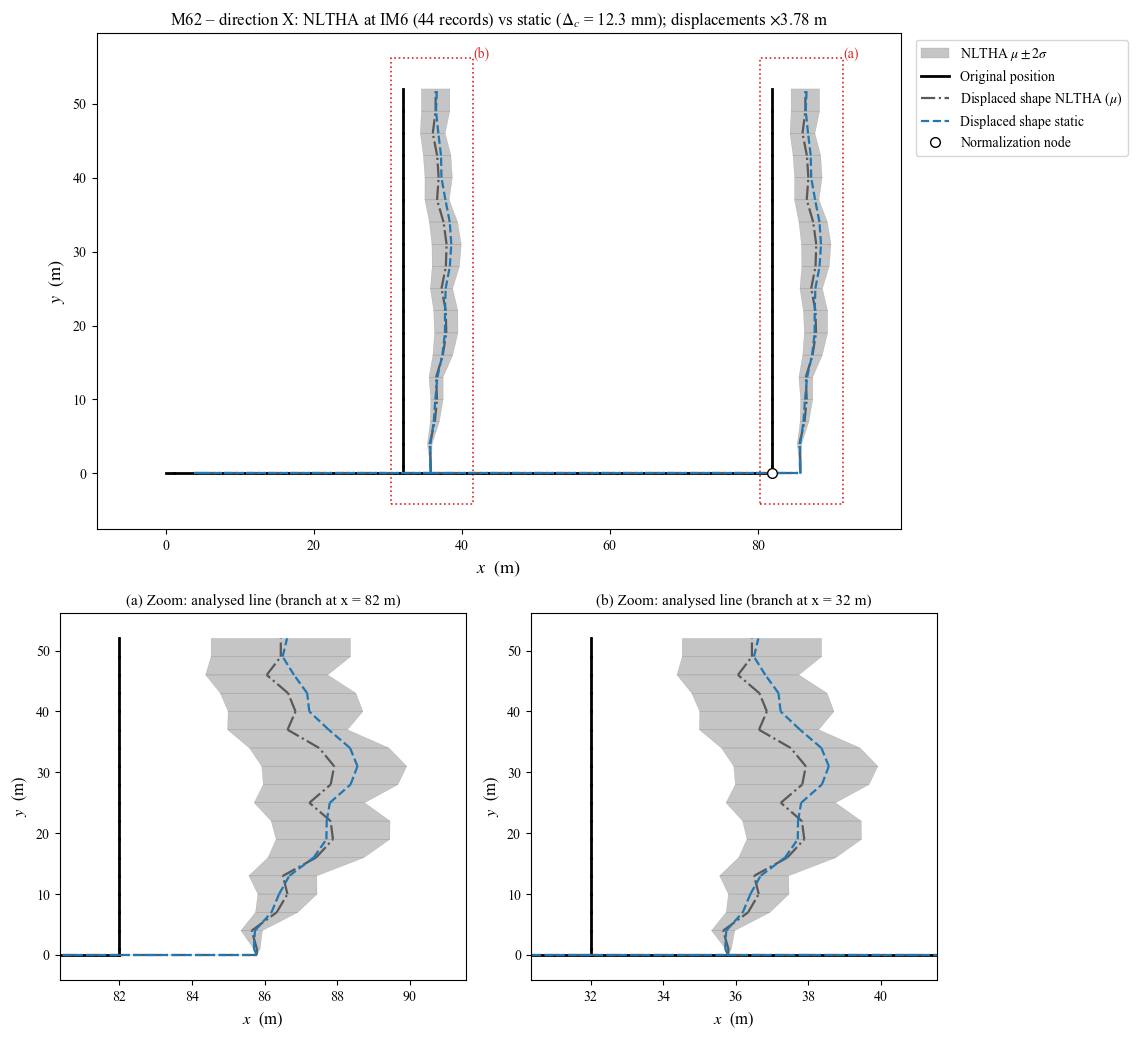

In [15]:
plot_displaced_shape(MODEL, 'X', SHAPE_IM, amp=AMP, dc_target=DC_TARGET)
plt.show()

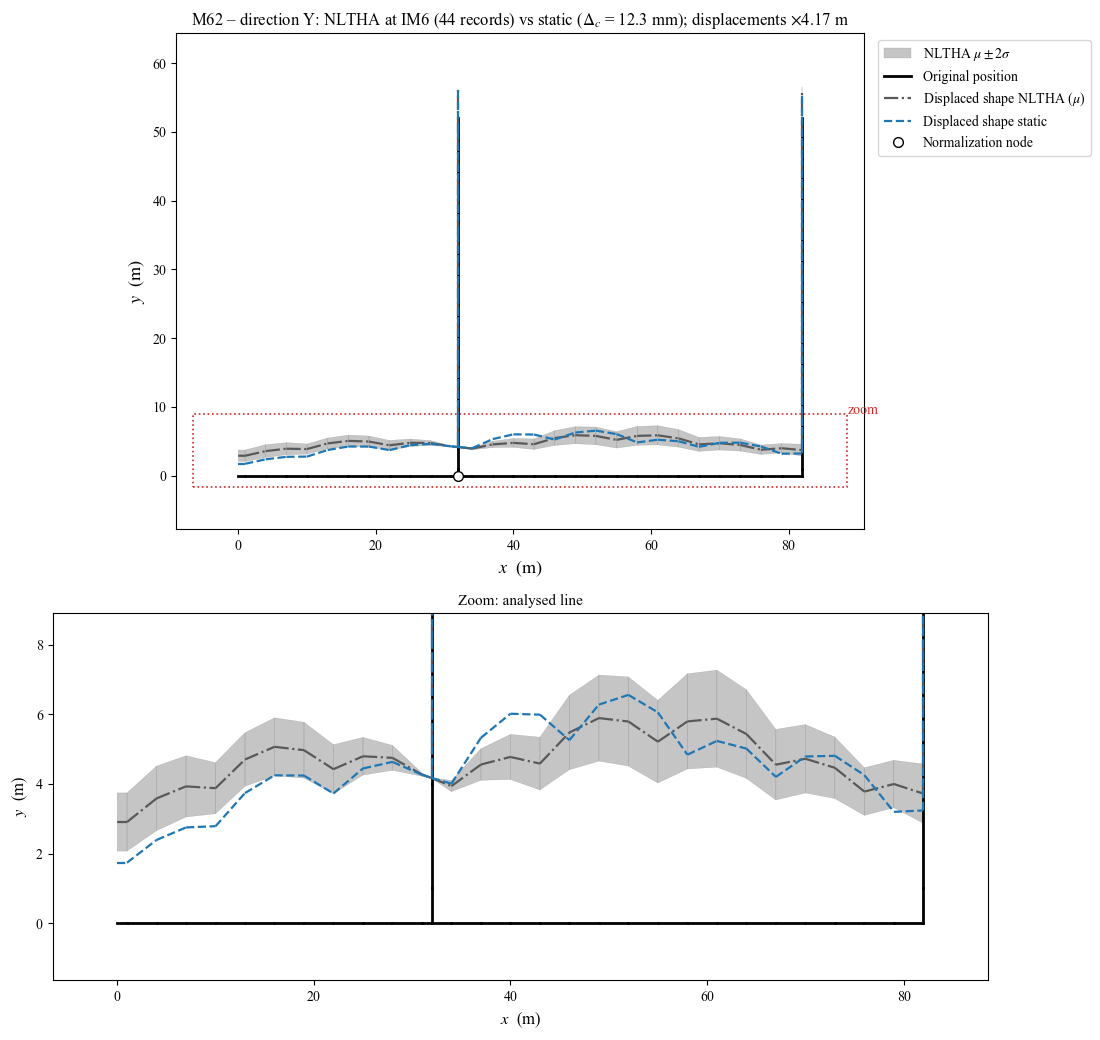

In [16]:
plot_displaced_shape(MODEL, 'Y', SHAPE_IM, amp=AMP, dc_target=DC_TARGET)
plt.show()